# Vector focusing and polarization

A scalar wave is a fine model for a focus at low numerical aperture.  At high NA
it is not: the pupil bends every ray toward the axis, the field is projected as
it bends, and a real fraction of the focal energy ends up in the **longitudinal**
component $E_z$ that points along the optical axis and carries no image
information.

`vectorwave` keeps the full vector field.  The object here is `Pupil`: it holds a
numerical aperture, an input polarization and (optionally) an aberration
wavefront, and `spectrum(grid)` applies the aplanatic **Richards–Wolf**
projection to hand back an `AngularSpectrum` we can synthesise anywhere.

Lengths in this notebook are in wavelengths, so a width of `1` means one $\lambda$.

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")            # keep the rendered output tidy

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm

import vectorwave as vw

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.titlesize": 10,
                     "figure.facecolor": "white"})
print("vectorwave", vw.__version__, "| packaged systems:", vw.available())

vectorwave 0.2.0 | packaged systems: ['duv', 'euv']


## 1 · A high-NA focus is not scalar

Focus an $x$-polarized pupil at NA 0.95 (dry) and split the focal intensity into
its three Cartesian components.  `field_on` synthesises the field on any grid we
ask for — exactly, by a zoom DFT — so the focal sampling is decoupled from the
grid that carries the spectrum.

NA 0.95:  |Ex|^2 = 0.745   |Ey|^2 = 0.0153   |Ez|^2 = 0.240
focal FWHM = 0.708 lambda   (Airy 0.541)


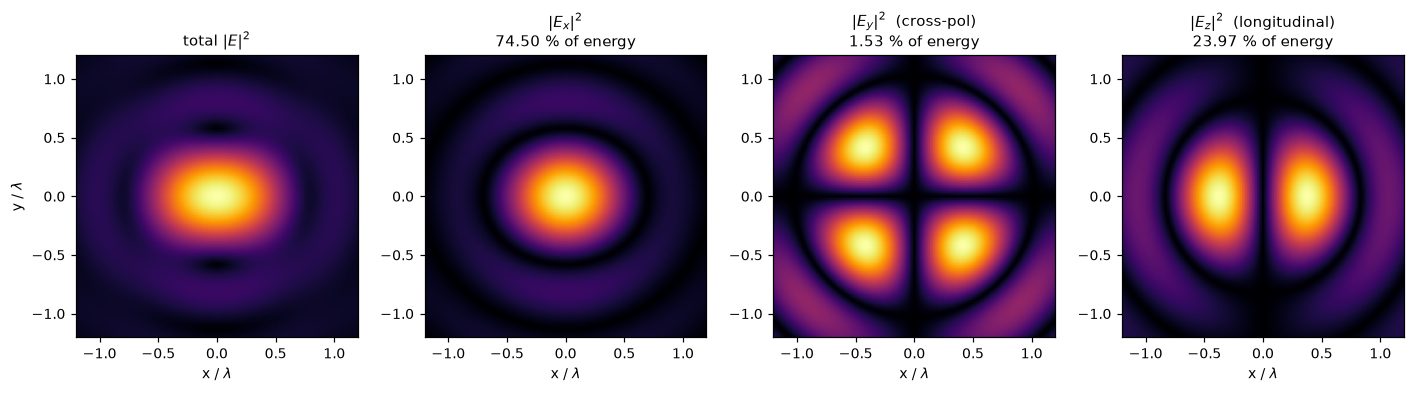

In [2]:
grid = vw.Grid.from_spacing(0.25, 256)
pupil = vw.Pupil(na=0.95, n=1.0, wavelength=1.0, polarization="x")

x = np.arange(-2.0, 2.0, 1 / 48)
field = pupil.spectrum(grid).field_on(x, x, z=0.0)

fr = field.component_fractions()
print(f"NA {pupil.na}:  |Ex|^2 = {fr['x']:.3f}   |Ey|^2 = {fr['y']:.4f}   "
      f"|Ez|^2 = {fr['z']:.3f}")
print(f"focal FWHM = {field.fwhm('x'):.3f} lambda   (Airy {pupil.airy_fwhm():.3f})")

ext = [x[0], x[-1], x[0], x[-1]]
comps = [("total $|E|^2$", field.intensity),
         ("$|E_x|^2$", np.abs(field.Ex) ** 2),
         ("$|E_y|^2$  (cross-pol)", np.abs(field.Ey) ** 2),
         ("$|E_z|^2$  (longitudinal)", np.abs(field.Ez) ** 2)]
fig, ax = plt.subplots(1, 4, figsize=(13, 3.3))
for a, (title, I) in zip(ax, comps):
    a.imshow(I, extent=ext, origin="lower", cmap="inferno", norm=PowerNorm(0.5))
    share = I.sum() / field.intensity.sum()
    a.set_title(title + ("" if "total" in title else f"\n{share*100:.2f} % of energy"))
    a.set_xlim(-1.2, 1.2); a.set_ylim(-1.2, 1.2); a.set_xlabel("x / $\\lambda$")
ax[0].set_ylabel("y / $\\lambda$")
fig.tight_layout()

The longitudinal lobe is split along $x$ — the input polarization direction —
because it comes from the meridional ($p$) part of the field that the pupil tips
into $z$.  The cross-polarized $|E_y|^2$ is a four-lobed clover, orders of
magnitude weaker.

## 2 · The longitudinal share follows $\mathrm{NA}^2/4n^2$

As the aperture closes, the longitudinal energy fraction of an aplanatic
$x$-pupil approaches the analytic low-NA limit $\mathrm{NA}^2/4n^2$.  This is the
scalar limit made quantitative — and one of the package's regression tests.

at NA 0.95 about a quarter of the energy is longitudinal: 0.256


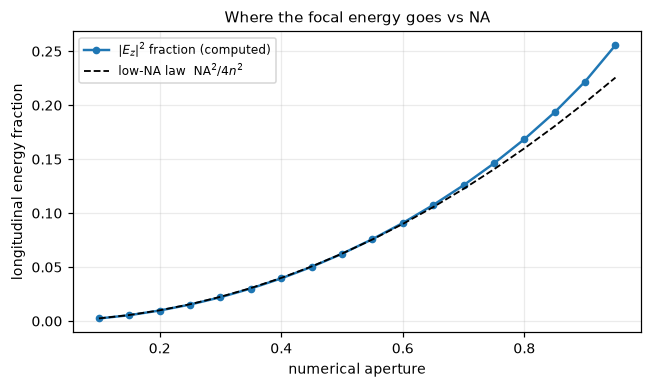

In [3]:
nas = np.linspace(0.1, 0.95, 18)
fz = []
g = vw.Grid.from_spacing(0.25, 512)
for na in nas:
    f = vw.Pupil(na=na, n=1.0, wavelength=1.0).spectrum(g).field(0.0)
    fz.append(f.component_fractions()["z"])
fz = np.array(fz)

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(nas, fz, "o-", lw=1.6, ms=4, label=r"$|E_z|^2$ fraction (computed)")
ax.plot(nas, nas ** 2 / 4, "k--", lw=1.2, label=r"low-NA law  $\mathrm{NA}^2/4n^2$")
ax.set_xlabel("numerical aperture"); ax.set_ylabel("longitudinal energy fraction")
ax.set_title("Where the focal energy goes vs NA")
ax.legend(fontsize=8); ax.grid(alpha=0.25)
fig.tight_layout()
print(f"at NA 0.95 about a quarter of the energy is longitudinal: {fz[-1]:.3f}")

## 3 · The focus matches the Airy pattern

For a moderate NA the vector PSF sits right on top of the ideal scalar Airy
pattern $\big(2J_1(v)/v\big)^2$ — the vector machinery reproduces the classical
result where the classical result is valid.

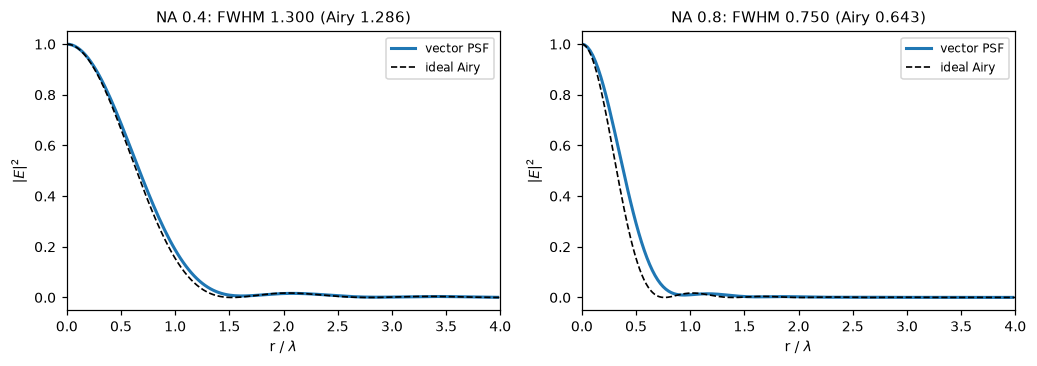

In [4]:
from scipy.special import j1

fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.4))
for a, na in zip(ax, (0.4, 0.8)):
    p = vw.Pupil(na=na, n=1.0, wavelength=1.0)
    xr = np.arange(-4, 4, 1 / 40)
    f = p.spectrum(g).field_on(xr, xr, 0.0)
    I = f.intensity / f.intensity.max()
    cut = I[I.shape[0] // 2]
    r = np.linspace(1e-3, 4, 400)
    v = 2 * np.pi * na * r
    airy = (2 * j1(v) / v) ** 2
    a.plot(xr, cut, lw=2, label="vector PSF")
    a.plot(r, airy, "k--", lw=1.1, label="ideal Airy")
    a.set_xlim(0, 4); a.set_xlabel("r / $\\lambda$"); a.set_ylabel("$|E|^2$")
    a.set_title(f"NA {na}: FWHM {f.fwhm('x'):.3f} (Airy {p.airy_fwhm():.3f})")
    a.legend(fontsize=8)
fig.tight_layout()

## 4 · Structured polarization reshapes the spot

The input polarization is any `(rho, phi) -> (Ex, Ey)` callable; a handful of
useful ones are named in `vw.POLARIZATIONS`.  At high NA they focus to visibly
different spots — the reason polarization is an engineering knob in microscopy
and lithography.

* **radial** collapses to a strong on-axis longitudinal spike (a sub-Airy core),
* **azimuthal** has a pure doughnut with a dark centre,
* **circular** stays compact and nearly round,
* **vortex** carries a phase singularity, so the centre is dark.

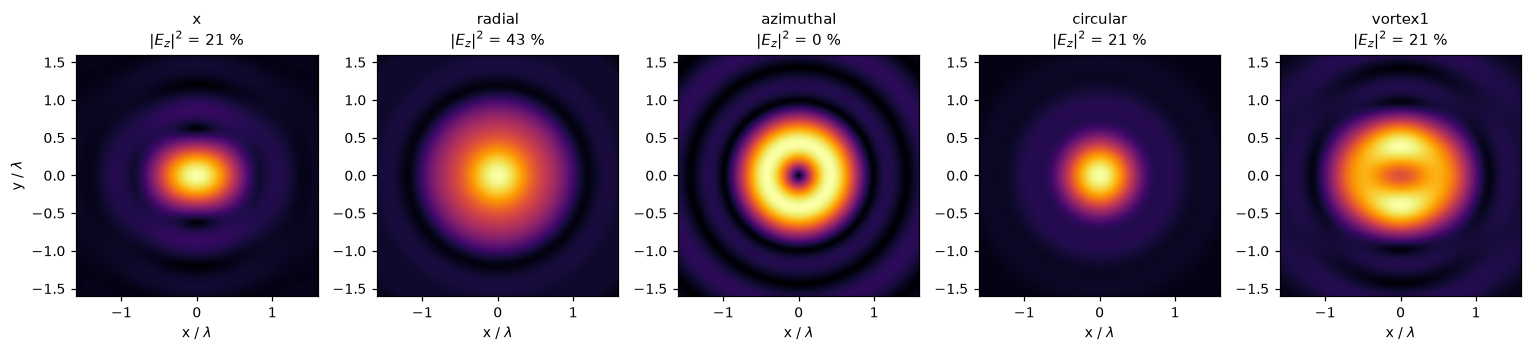

In [5]:
states = ["x", "radial", "azimuthal", "circular", "vortex1"]
xr = np.arange(-2.5, 2.5, 1 / 40)
fig, ax = plt.subplots(1, len(states), figsize=(14, 3.1))
for a, s in zip(ax, states):
    f = vw.Pupil(na=0.9, n=1.0, polarization=s).spectrum(g).field_on(xr, xr, 0.0)
    a.imshow(f.intensity, extent=[xr[0], xr[-1], xr[0], xr[-1]], origin="lower",
             cmap="inferno", norm=PowerNorm(0.5))
    fz = f.component_fractions()["z"]
    a.set_title(f"{s}\n$|E_z|^2$ = {fz*100:.0f} %")
    a.set_xlim(-1.6, 1.6); a.set_ylim(-1.6, 1.6); a.set_xlabel("x / $\\lambda$")
ax[0].set_ylabel("y / $\\lambda$")
fig.tight_layout()

Radial polarization puts **roughly 40 %** of the focal energy into $E_z$ at NA 0.9
— an on-axis longitudinal spike that is narrower than the transverse Airy core,
which is why radially-polarized beams are used to beat the scalar spot size.
Azimuthal input is the complement: a purely transverse doughnut with no $E_z$ at
all.

## 5 · The polarization is no longer uniform

Once the pupil bends the rays, the transverse field stops being uniformly
polarized.  The Stokes parameters of the focal field (`field.polarization()`)
give the ellipse orientation and ellipticity point by point.

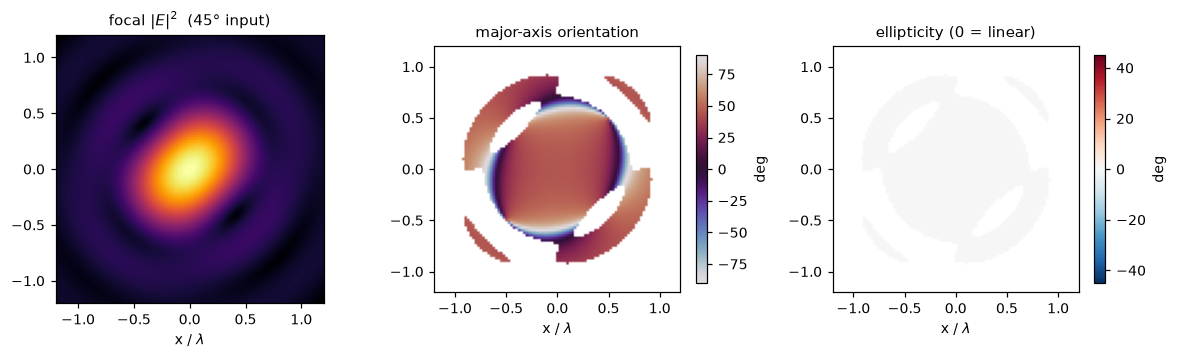

In [6]:
xr = np.arange(-2.0, 2.0, 1 / 40)
f = vw.Pupil(na=0.95, polarization="45").spectrum(g).field_on(xr, xr, 0.0)
pol = f.polarization()
ext = [xr[0], xr[-1], xr[0], xr[-1]]
bright = f.intensity > 0.02 * f.intensity.max()

fig, ax = plt.subplots(1, 3, figsize=(11, 3.3))
ax[0].imshow(f.intensity, extent=ext, origin="lower", cmap="inferno", norm=PowerNorm(0.5))
ax[0].set_title("focal $|E|^2$  (45$\\degree$ input)")
im = ax[1].imshow(np.where(bright, np.degrees(pol.orientation), np.nan),
                  extent=ext, origin="lower", cmap="twilight", vmin=-90, vmax=90)
ax[1].set_title("major-axis orientation"); plt.colorbar(im, ax=ax[1], shrink=0.85, label="deg")
im = ax[2].imshow(np.where(bright, np.degrees(pol.ellipticity), np.nan),
                  extent=ext, origin="lower", cmap="RdBu_r", vmin=-45, vmax=45)
ax[2].set_title("ellipticity (0 = linear)"); plt.colorbar(im, ax=ax[2], shrink=0.85, label="deg")
for a in ax:
    a.set_xlim(-1.2, 1.2); a.set_ylim(-1.2, 1.2); a.set_xlabel("x / $\\lambda$")
fig.tight_layout()

## 6 · Through focus

The same spectrum evaluated over a range of $z$ gives the axial structure.
`spectrum.meridional` returns the field in the $(x, z)$ plane in one call.

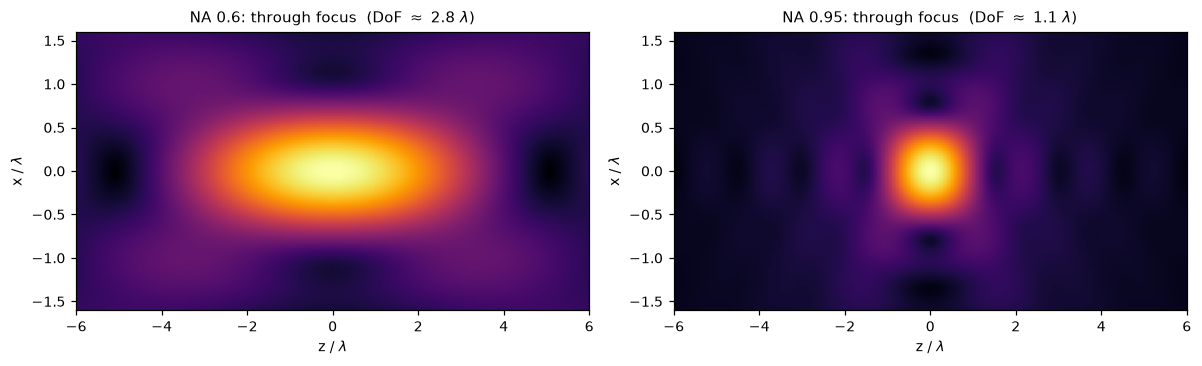

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for a, na in zip(ax, (0.6, 0.95)):
    spec = vw.Pupil(na=na, n=1.0).spectrum(g)
    xs = np.arange(-2.0, 2.0, 1 / 32)
    zs = np.linspace(-6, 6, 141)
    comp, _, _ = spec.meridional(xs, zs)
    I = np.sum(np.abs(comp) ** 2, axis=0)
    a.imshow(I.T, extent=[zs[0], zs[-1], xs[0], xs[-1]], origin="lower",
             aspect="auto", cmap="inferno", norm=PowerNorm(0.5))
    dof = 1.0 / na ** 2
    a.set_title(f"NA {na}: through focus  (DoF $\\approx$ {dof:.1f} $\\lambda$)")
    a.set_xlabel("z / $\\lambda$"); a.set_ylabel("x / $\\lambda$"); a.set_ylim(-1.6, 1.6)
fig.tight_layout()

The higher aperture buys a tighter waist at the cost of a shorter depth of focus
— the axial hourglass narrows in both directions.  That trade is exactly what the
two production objectives in notebook 3 navigate.